['ï»¿Frequency (Hz)', 'Output level (dBm)', '"Trace 1: Gain: Real "', '"Trace 1: Gain: Imaginary "', 'Trace 1: Gain: Magnitude (dB)', '"Trace 2: Gain: Real "', '"Trace 2: Gain: Imaginary "', 'Trace 2: Gain: Phase (Â°)\n']
['1A3: Frequency (Hz)', '"1A3: Trace 1: Gain Real "', '"1A3: Trace 1: Gain Imaginary "', '1A3: Trace 1: Magnitude (dB)', '"1A3: Trace 2: Gain Real "', '"1A3: Trace 2: Gain Imaginary "', '1A3: Trace 2: Phase (Â°)\n']
['2A3: Frequency (Hz)', '"2A3: Trace 1: Gain Real "', '"2A3: Trace 1: Gain Imaginary "', '2A3: Trace 1: Magnitude (dB)', '"2A3: Trace 2: Gain Real "', '"2A3: Trace 2: Gain Imaginary "', '2A3: Trace 2: Phase (Â°)\n']
['4A5: Frequency (Hz)', '"4A5: Trace 1: Gain Real "', '"4A5: Trace 1: Gain Imaginary "', '4A5: Trace 1: Magnitude (dB)', '"4A5: Trace 2: Gain Real "', '"4A5: Trace 2: Gain Imaginary "', '4A5: Trace 2: Phase (Â°)\n']
['7A8: Frequency (Hz)', '"7A8: Trace 1: Gain Real "', '"7A8: Trace 1: Gain Imaginary "', '7A8: Trace 1: Magnitude (dB)', '"7A8: Tr

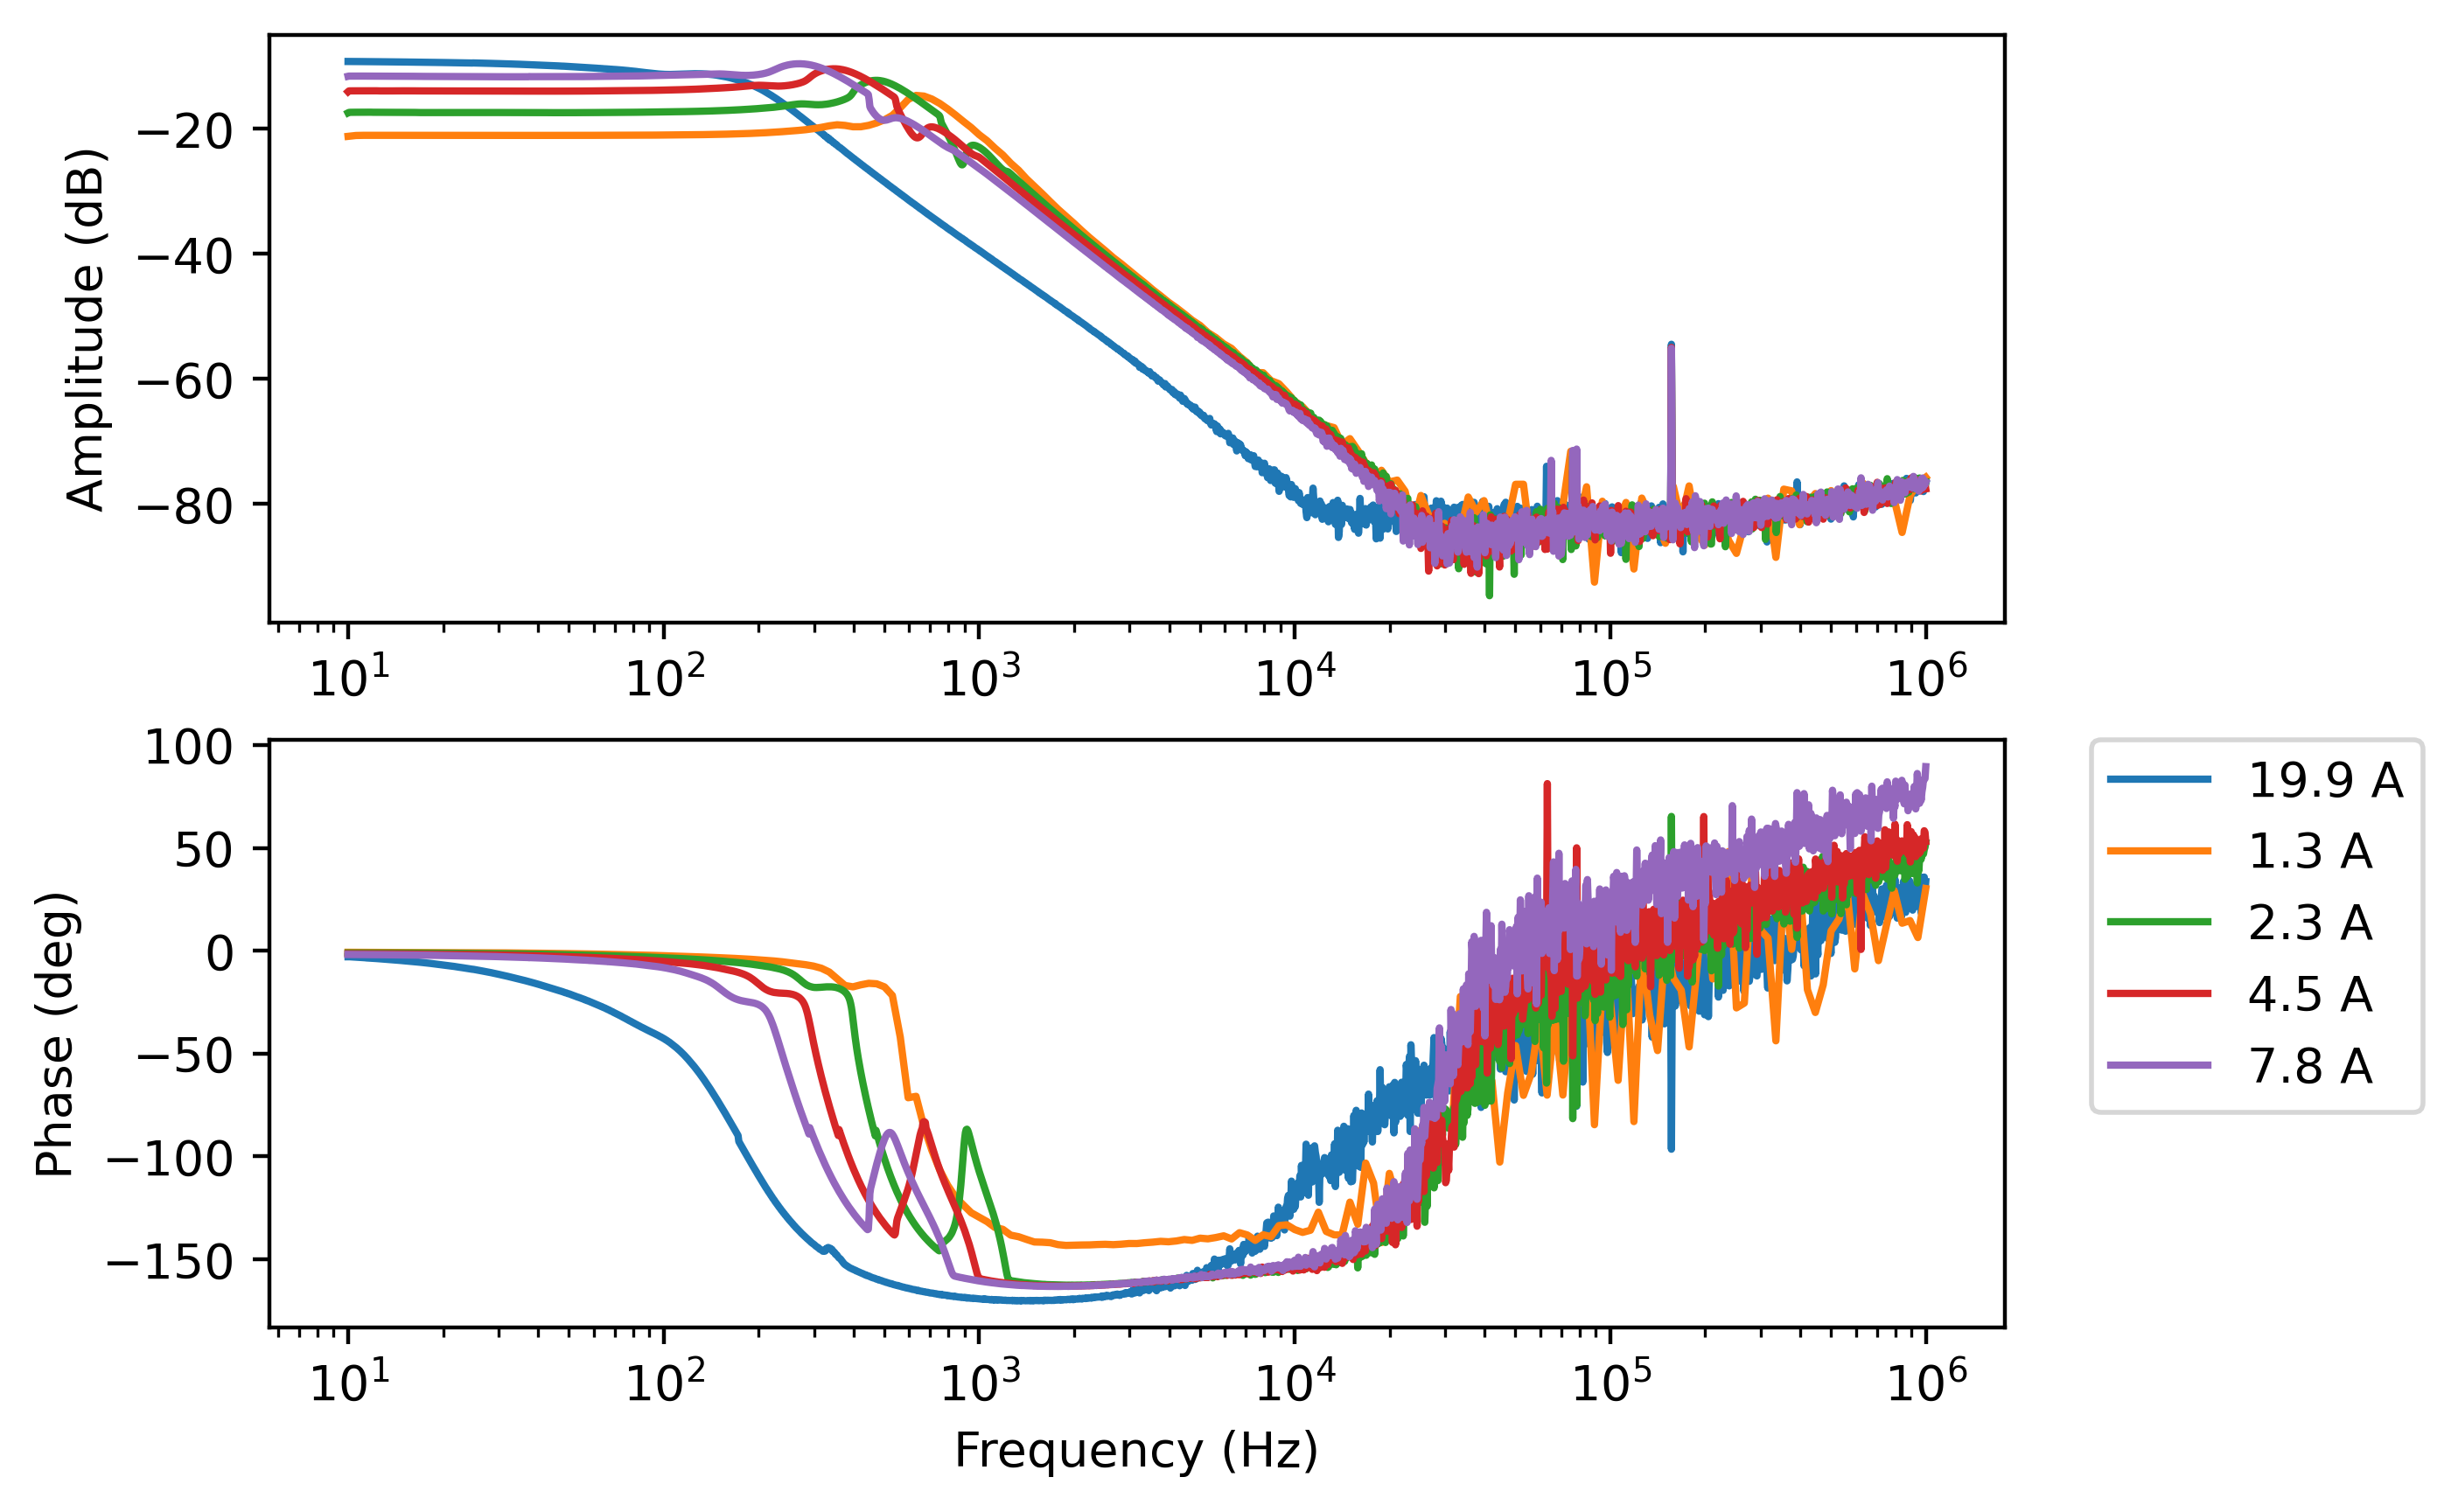

In [87]:
import numpy as np
from matplotlib import pyplot as plt

def load_bode_100(file):
    with open(file) as f:
        
        current = [] 
        frame = []
        for line in f:
            fields = line.split(';')
            if fields[0] == f"\n" :
                # ignores empty lanes
                pass
            else:
                try:
                    current.append([float(d) for d in fields][:-1])
                except:
                    # If it can't convert the data it means that we have to save current data in frame
                    print(fields) #So we know what is in the list
                    frame.append(np.array(current).T)
                    current = []
                
    #Returns a list of numpy arrays (removes the first empty array triggered by the first title row)
    return frame[1:]

data = load_bode_100('./data/2024_09_26/MOS_and_network_2024-09-26T11_03_29.csv')


#Note: we did not save the last measurement as "memory" Consequently it was saved with an extra
#      parameter: Output level. The following line of code removes such parameter.
data[0] = np.delete(data[0],1,0)


plt.figure(dpi=400)
ax1 = plt.subplot(2,1,1)
plt.ylabel('Amplitude (dB)',fontsize=10)

ax2 = plt.subplot(2,1,2)
plt.xlabel('Frequency (Hz)',fontsize=10)
plt.ylabel('Phase (deg)',fontsize=10)


for plot in data:

    frequency = plot[0]
    ampl_db = plot[3]
    real = plot[1]
    imag = plot [2]

    phase_deg = np.unwrap ( 180/np.pi * np.arctan(imag/real) , discont= 90)
    ax1.semilogx(frequency,ampl_db)
    ax2.semilogx(frequency,phase_deg)

# Note: this is the order data are loaded in the list of numpy arrays
plt.legend(["19.9 A","1.3 A", "2.3 A","4.5 A", "7.8 A", "14.2 A"],bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
